In [85]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [86]:
df=pd.read_csv("data.csv")

In [87]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Data Preprocessing


In [88]:
df['Income']=df['Income'].fillna(df['Income'].mean())

In [89]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [90]:
df['Income'].head(5)

,Income
0,58138.0
1,46344.0
2,71613.0
3,26646.0
4,58293.0


In [91]:
df['Age']=2026-df['Year_Birth']

In [92]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [93]:
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [94]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True)

In [95]:
ref_Date=df['Dt_Customer'].max()

In [96]:
df['Customer_Tenure_Days']=(ref_Date-df['Dt_Customer']).dt.days

In [97]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [98]:
df['total_spending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [99]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [100]:
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

In [101]:
df['Education'].unique()

array(['Graduation', 'PhD', 'Master', 'Basic', '2n Cycle'], dtype=object)

In [102]:
df['Education'] = df['Education'].replace({'Basic':'Undergraduate', '2n Cycle':'Undergraduate', 'Graduation':'Graduate', 'Master':'Postgraduate', 'PhD':'Postgraduate'})

In [103]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spending,Total_Children
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [104]:
df['Marital_Status'].unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [105]:
df['Marital_Status'].replace({'Married':'Living_with_partner', 'Together':'Living_with_partner', 'Divorced':'Alone', 'Widow':'Alone', 'Alone':'Alone', 'Absurd':'Alone', 'YOLO':'Alone','Single':'Alone'}, inplace=True)

/tmp/ipykernel_2920/1573962447.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Marital_Status'].replace({'Married':'Living_with_partner', 'Together':'Living_with_partner', 'Divorced':'Alone', 'Widow':'Alone', 'Alone':'Alone', 'Absurd':'Alone', 'YOLO':'Alone','Single':'Alone'}, inplace=True)


In [106]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spending,Total_Children
0,5524,1957,Graduate,Alone,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduate,Alone,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduate,Living_with_partner,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduate,Living_with_partner,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,Postgraduate,Living_with_partner,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [107]:
df['Education'].value_counts()

,count
Education,
Graduate,1127
Postgraduate,856
Undergraduate,257


In [108]:
df['Education'].value_counts()

,count
Education,
Graduate,1127
Postgraduate,856
Undergraduate,257


In [109]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
Living_with_partner,1444
Alone,796


In [110]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'total_spending',
       'Total_Children'],
      dtype='object')

In [111]:
cols=['ID','Year_Birth','Kidhome','Teenhome','Dt_Customer','MntWines','MntMeatProducts','MntFruits','MntFishProducts','MntSweetProducts','MntGoldProds']

In [112]:
df.drop(columns=cols, errors='ignore', inplace=True)

In [113]:
df.head()

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spending,Total_Children
0,Graduate,Alone,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0
1,Graduate,Alone,46344.0,38,2,1,1,2,5,0,0,72,113,27,2
2,Graduate,Living_with_partner,71613.0,26,1,8,2,10,4,0,0,61,312,776,0
3,Graduate,Living_with_partner,26646.0,26,2,2,0,4,6,0,0,42,139,53,1
4,Postgraduate,Living_with_partner,58293.0,94,5,5,3,6,5,0,0,45,161,422,1


Outlier


In [114]:
cols=['Income','Recency','Response','total_spending','Total_Children','Age']

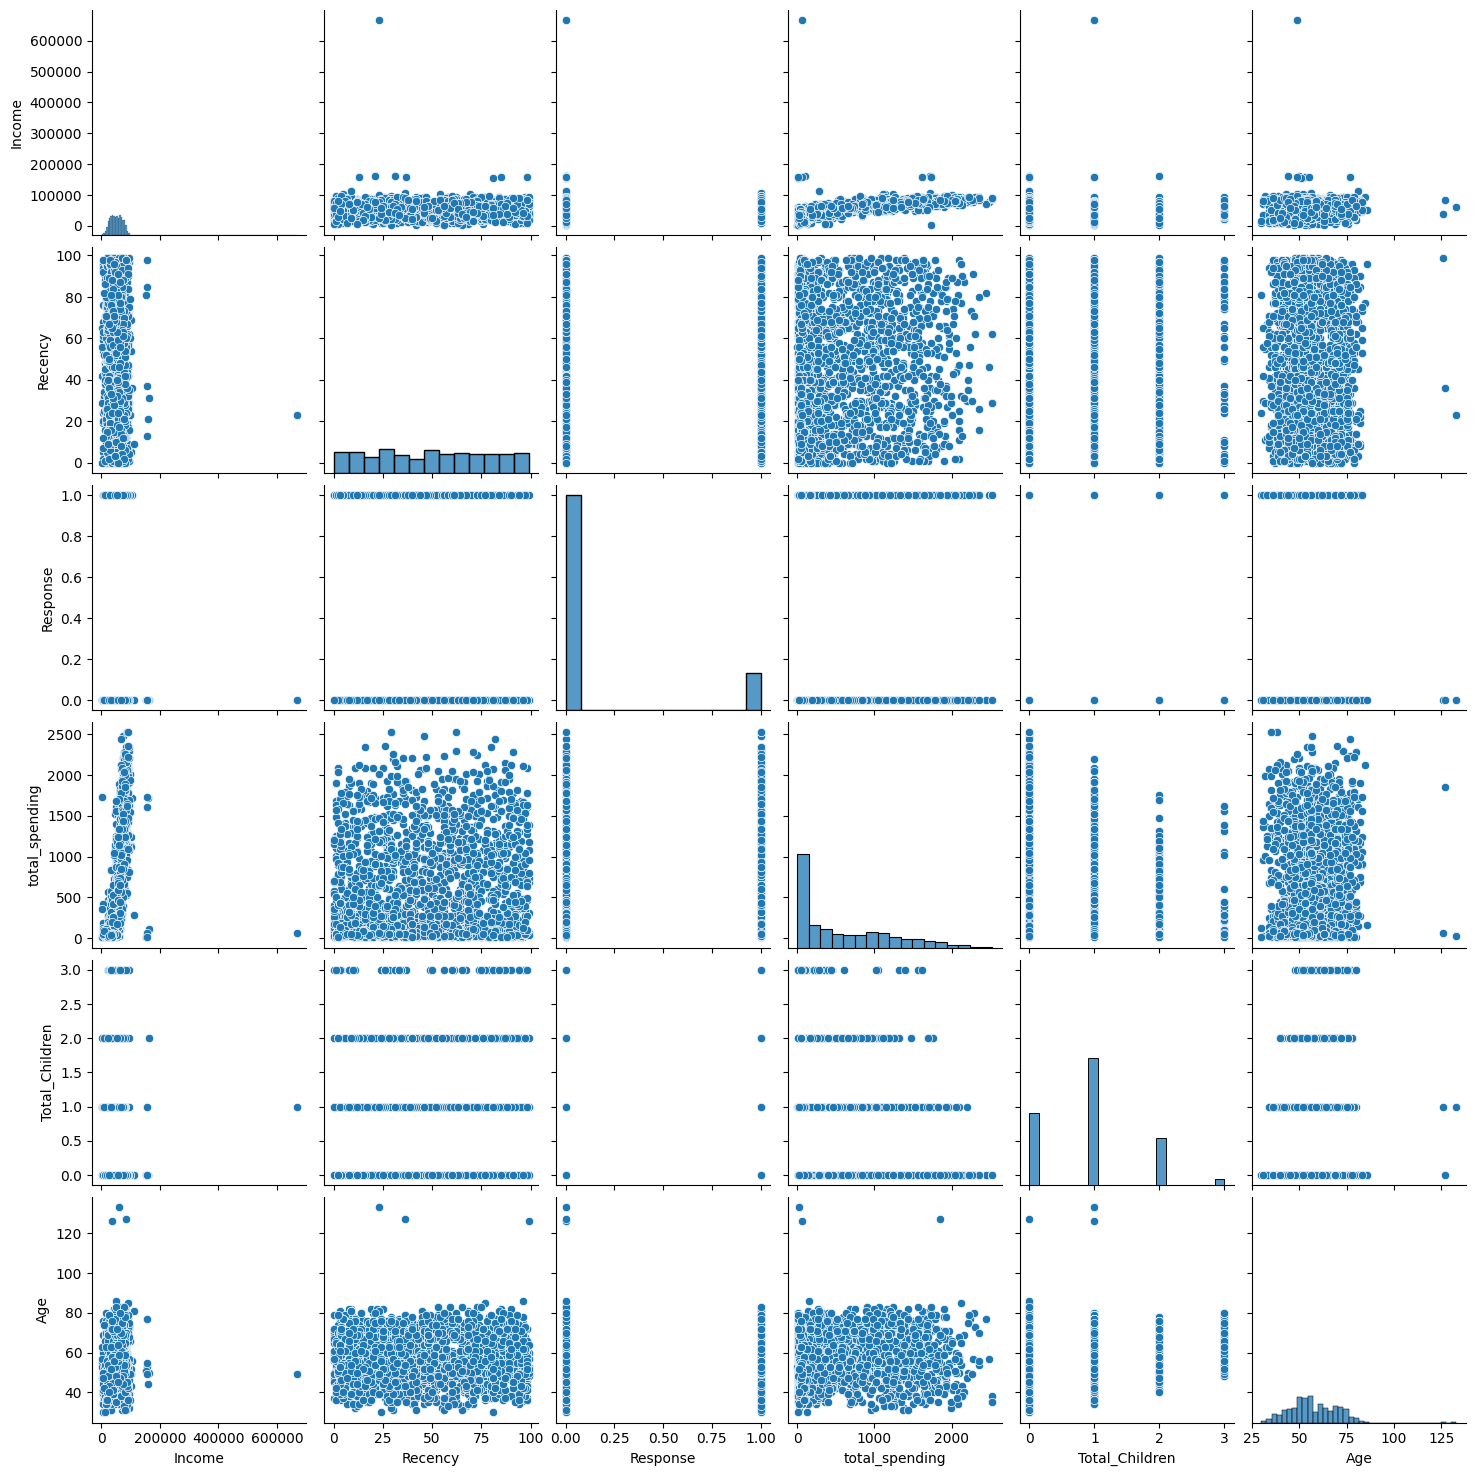

In [115]:
sns.pairplot(df[cols])

In [116]:
# df['Age'] = df['Age'].apply(lambda x: x < 80)

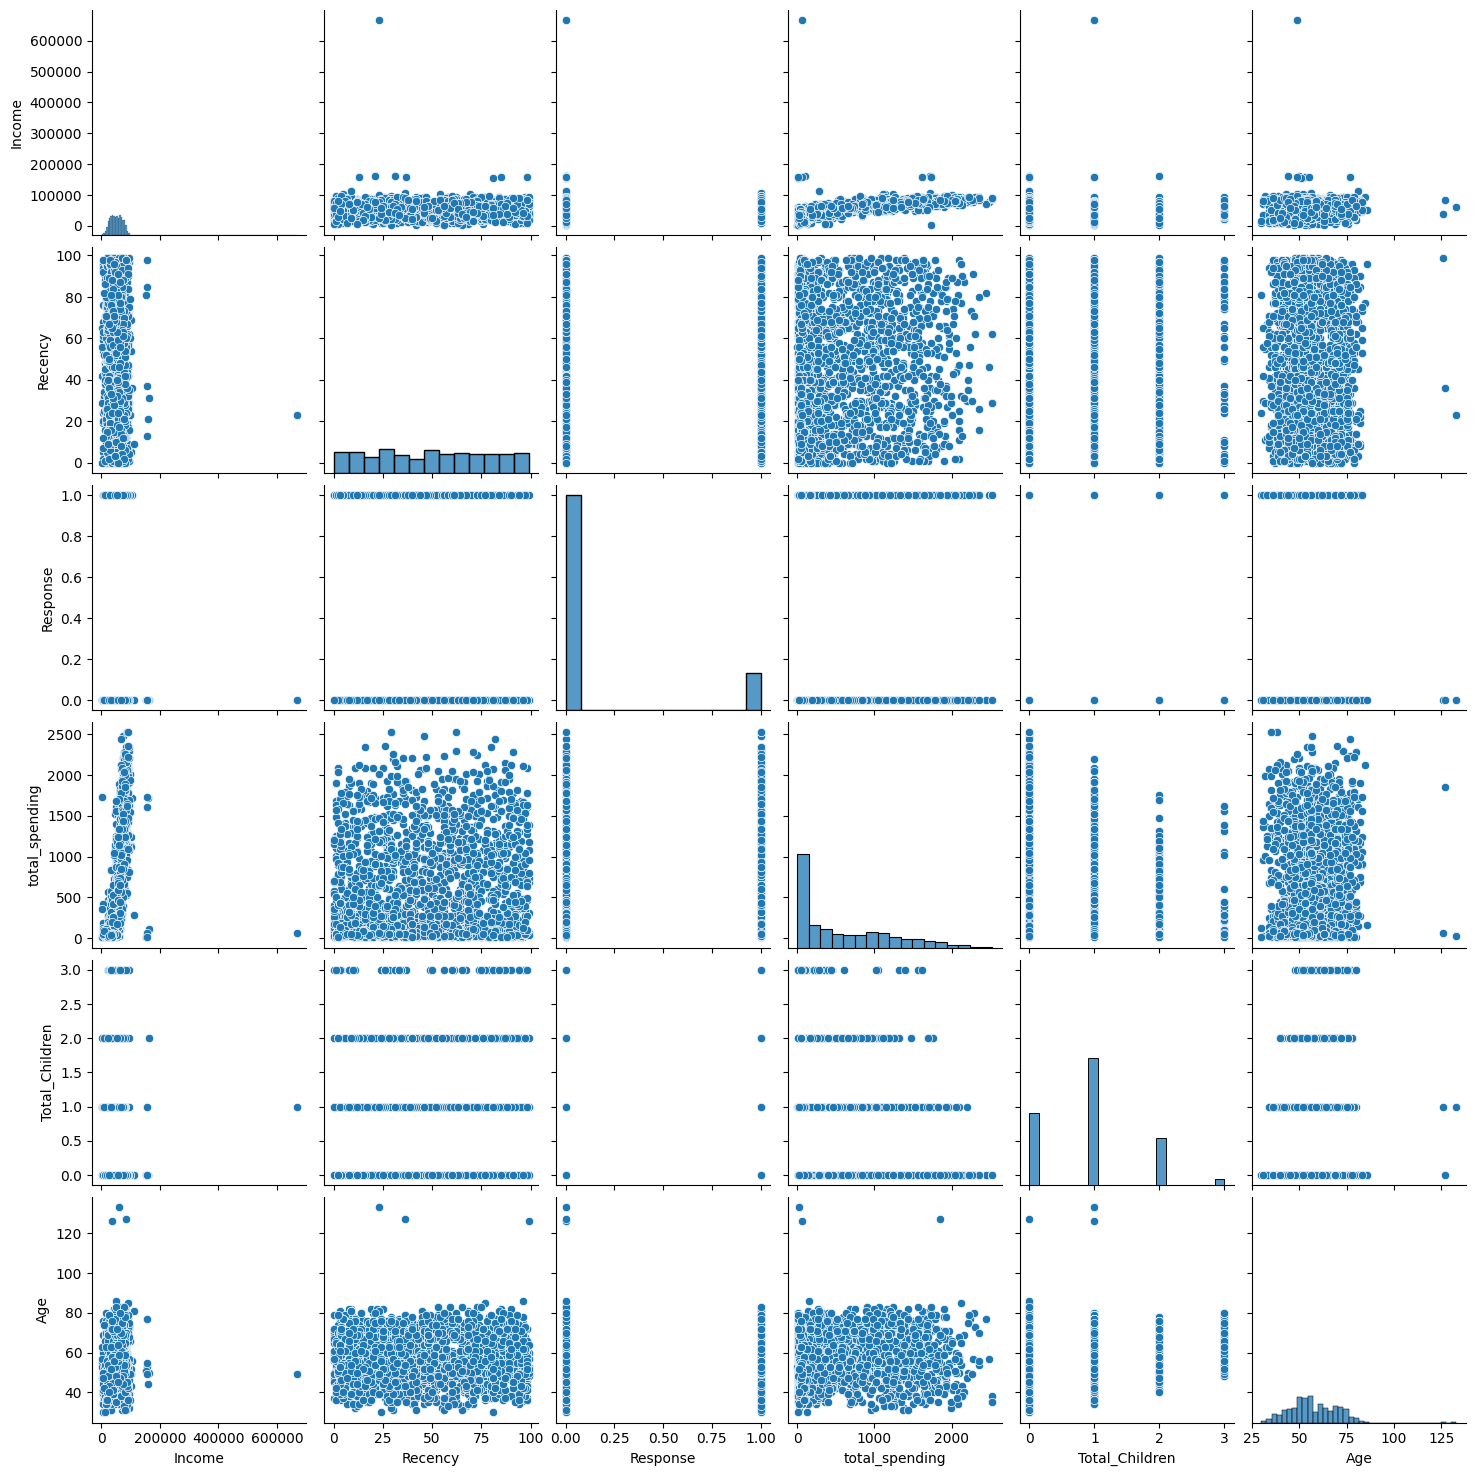

In [117]:
sns.pairplot(df[cols])

In [118]:
len(df)

2240

In [119]:
df=df[(df['Age']<90)]
df=df[(df['Income']<600000)]


In [120]:
len(df)

2236

Heatmap


In [121]:
corr=df.corr(numeric_only=True)

<Axes: >

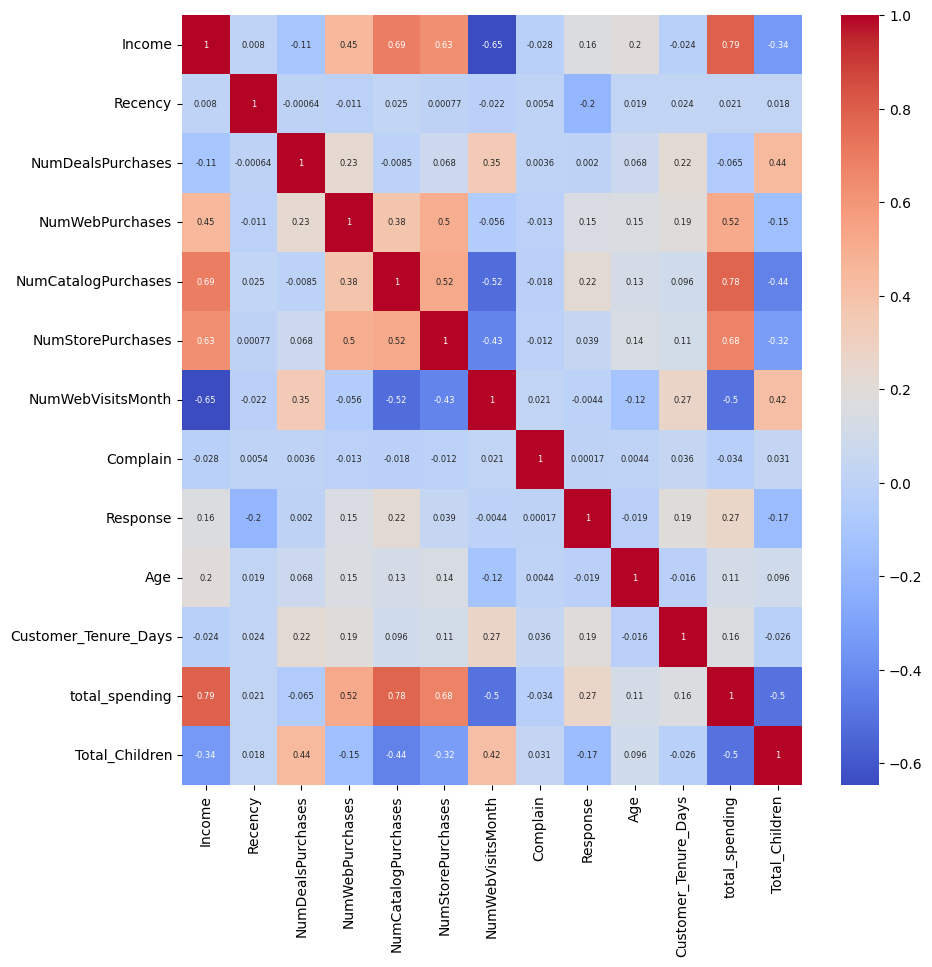

In [122]:
plt.figure(figsize=(10,10))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={'size':6},
    cmap='coolwarm'
)

In [123]:
from sklearn.preprocessing import OneHotEncoder

In [124]:
df.head()

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spending,Total_Children
0,Graduate,Alone,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0
1,Graduate,Alone,46344.0,38,2,1,1,2,5,0,0,72,113,27,2
2,Graduate,Living_with_partner,71613.0,26,1,8,2,10,4,0,0,61,312,776,0
3,Graduate,Living_with_partner,26646.0,26,2,2,0,4,6,0,0,42,139,53,1
4,Postgraduate,Living_with_partner,58293.0,94,5,5,3,6,5,0,0,45,161,422,1


In [125]:
one=OneHotEncoder()

In [126]:
cat_cols=['Education','Marital_Status']

In [127]:
enc=one.fit_transform(df[cat_cols])

In [128]:
df_enc=pd.DataFrame(enc.toarray(),columns=one.get_feature_names_out(cat_cols),index=df.index)

In [129]:
df_enc.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Marital_Status_Alone,Marital_Status_Living_with_partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [130]:
# df_encoding=pd.concat([df,df_enc],axis=1)

df_encoding=pd.concat([df.drop(cat_cols,axis=1),df_enc],axis=1)

In [131]:
df_encoding.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Marital_Status_Alone,Marital_Status_Living_with_partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [132]:
df_encoding.shape

(2236, 18)

In [133]:
df.describe()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spending,Total_Children
count,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000,2236.000000
mean,51961.906544,49.116279,2.326029,4.087657,2.663238,5.795617,5.318873,0.008945,0.149374,57.101968,353.773256,605.986583,0.950805
std,21411.404811,28.957284,1.933032,2.779988,2.923898,3.251129,2.426886,0.094173,0.356536,11.703281,202.181561,601.865156,0.752204
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000,5.000000,0.000000
25%,35502.500000,24.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,49.000000,180.750000,69.000000,0.000000
50%,51684.000000,49.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,56.000000,356.000000,396.500000,1.000000
75%,68275.750000,74.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,67.000000,529.000000,1045.500000,1.000000
max,162397.000000,99.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,86.000000,699.000000,2525.000000,3.000000


In [134]:
df_encoding.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2236 entries, 0 to 2239
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Income                              2236 non-null   float64
 1   Recency                             2236 non-null   int64  
 2   NumDealsPurchases                   2236 non-null   int64  
 3   NumWebPurchases                     2236 non-null   int64  
 4   NumCatalogPurchases                 2236 non-null   int64  
 5   NumStorePurchases                   2236 non-null   int64  
 6   NumWebVisitsMonth                   2236 non-null   int64  
 7   Complain                            2236 non-null   int64  
 8   Response                            2236 non-null   int64  
 9   Age                                 2236 non-null   int64  
 10  Customer_Tenure_Days                2236 non-null   int64  
 11  total_spending                      2236 non-nul

**Data Visualize**



In [135]:
from sklearn.preprocessing import StandardScaler

In [136]:
X=df_encoding

In [137]:
scaler=StandardScaler()

In [138]:
x_sclaed=scaler.fit_transform(X)

In [139]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)

In [140]:
X_pca=pca.fit_transform(x_sclaed)

<Axes: >

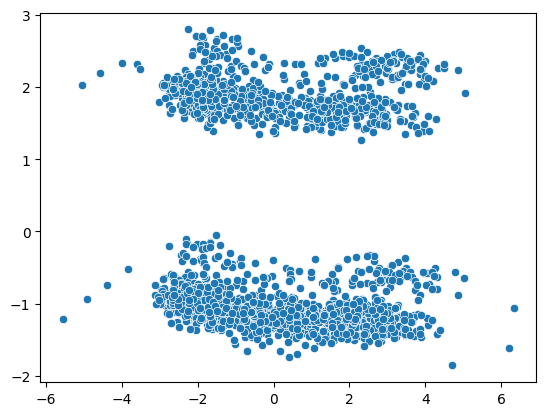

In [141]:
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1])

In [142]:
pca.explained_variance_ratio_

array([0.23162286, 0.11385437, 0.1040582 ])

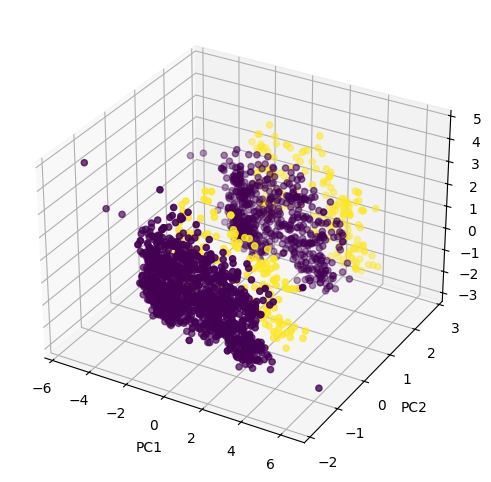

In [143]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=df['Response'])
# sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=df['Response'])
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()
#

In [144]:
!pip install kneed
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [145]:
wcss = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(x_sclaed)
    wcss.append(model.inertia_)

In [146]:
kneed=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
optimal_k=kneed.elbow

In [147]:
optimal_k

np.int64(4)

Plot K

Text(0.5, 1.0, 'Elbow Method')

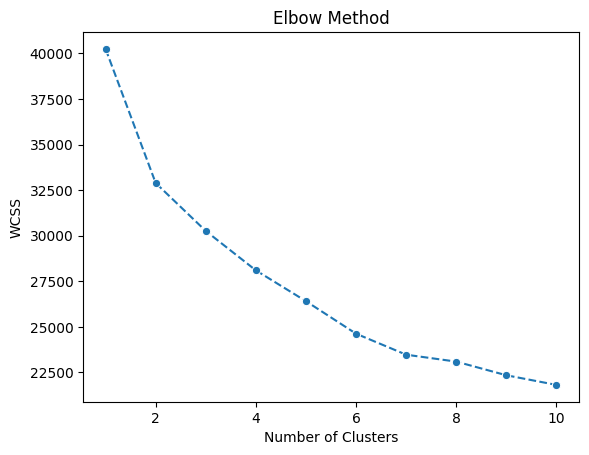

In [148]:
sns.lineplot(x=range(1,11), y=wcss, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')

In [149]:
from sklearn.metrics import silhouette_score


In [150]:
score=[]
for k in range(2,11):
  model=KMeans(n_clusters=k,random_state=42)
  labels=model.fit_predict(X_pca)
  score.append(silhouette_score(X_pca,labels))

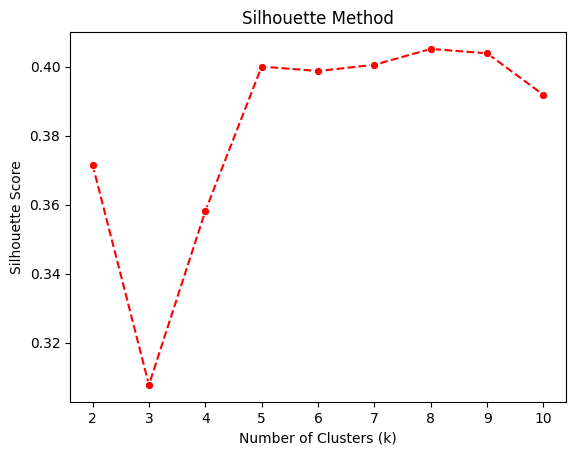

In [151]:
sns.lineplot(x=range(2, 11), y=score, marker='o', linestyle='--', color='red')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method')
plt.show()

Text(0.5, 1.0, 'Silhouette Method')

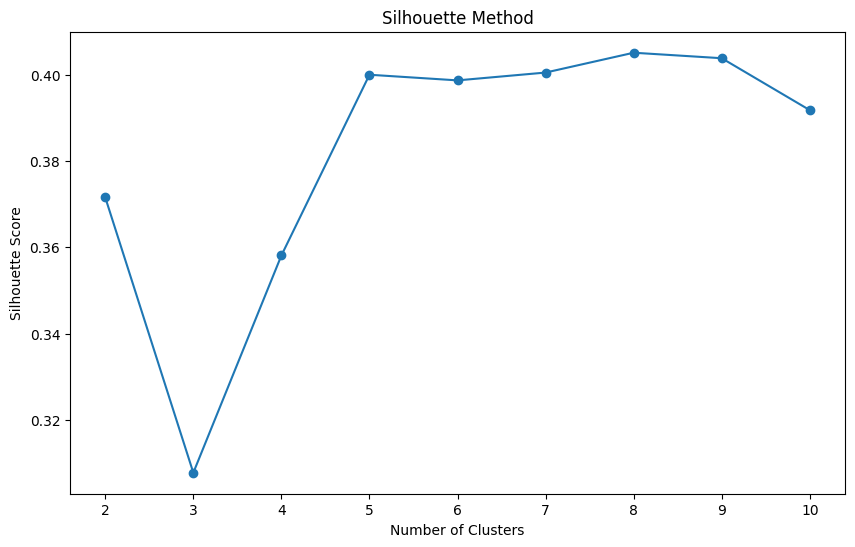

In [152]:
k_range=range(2,11)
fig,ax=plt.subplots(figsize=(10,6))
ax.plot(k_range,score,marker='o')
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Method')

Kmeans Clustering

In [153]:
model=KMeans(n_clusters=4,random_state=42)

In [154]:
labels=model.fit_predict(X_pca)

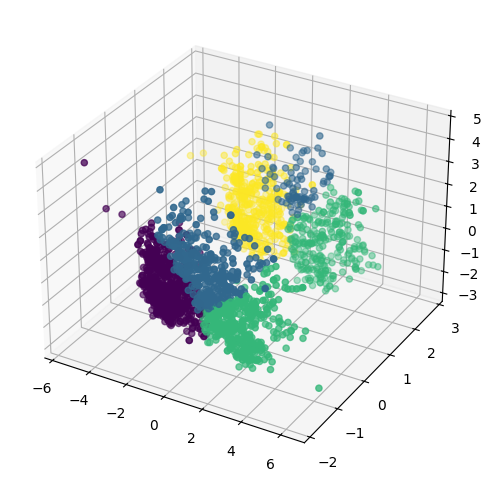

In [155]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels)

In [156]:
from sklearn.cluster import AgglomerativeClustering

In [157]:
age_clf=AgglomerativeClustering(n_clusters=4,linkage='ward')
age_labels=age_clf.fit_predict(X_pca)

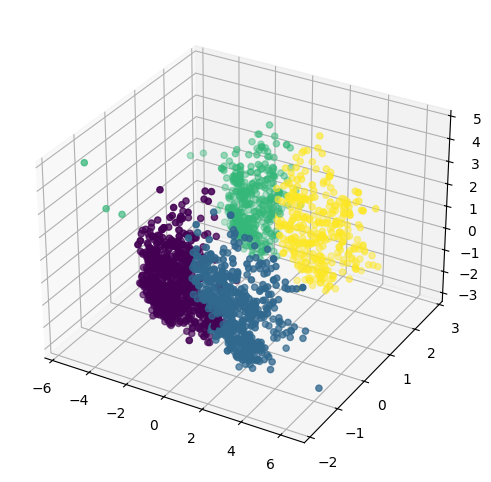

In [158]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=age_labels)

In [165]:
X['Cluster']=age_labels

In [160]:
pal=["red","yellow","green","blue"]

<Axes: xlabel='Cluster', ylabel='count'>

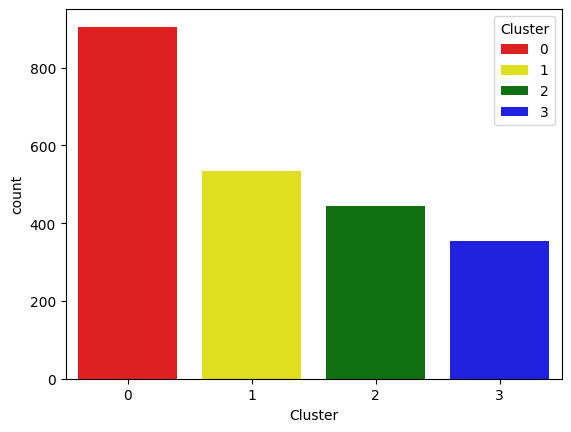

In [166]:
sns.countplot(x=X['Cluster'],palette=pal,hue=X['Cluster'])

In [162]:
df.head()

,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spending,Total_Children,Cluster
0,Graduate,Alone,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,3
1,Graduate,Alone,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,2
2,Graduate,Living_with_partner,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1
3,Graduate,Living_with_partner,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0
4,Postgraduate,Living_with_partner,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0


In [163]:
#income and Spending

<Axes: xlabel='Income', ylabel='total_spending'>

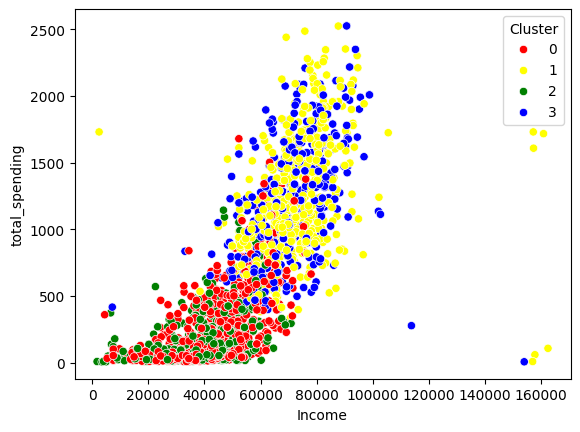

In [167]:
sns.scatterplot(x=X['Income'],y=X['total_spending'],hue=X['Cluster'],palette=pal)

Cluster Summary

In [169]:
cluster_summary=X.groupby('Cluster').mean()

In [170]:
cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,total_spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Marital_Status_Alone,Marital_Status_Living_with_partner
Cluster,,,,,,,,,,,,,,,,,,
0,39690.146424,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,342.939227,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72814.930722,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,369.720974,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36973.792251,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,338.781532,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70730.038963,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,376.280453,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000


requirements.txt has been created successfully!
